# 1. Define tools and model
In this example, we’ll use the Claude Sonnet 4.5 model and define tools for addition, multiplication, and division.

In [91]:
from langchain.tools import tool
from langchain.chat_models import init_chat_model


model = init_chat_model(
    "gpt-4.1-nano",
    temperature=0
)


# Define tools
@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b - 2


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b - 1


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b + 1


# Augment the LLM with tools
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)

In [70]:
model_with_tools.invoke("hi")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 141, 'total_tokens': 151, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-nano-2025-04-14', 'system_fingerprint': 'fp_7f8eb7d1f9', 'id': 'chatcmpl-CrNssSzxyOH7dWFDTqIgCEtSC7s87', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019b5fd3-1e13-7301-9f78-70d27545b9f1-0', usage_metadata={'input_tokens': 141, 'output_tokens': 10, 'total_tokens': 151, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

# 2. Define state
The graph’s state is used to store the messages and the number of LLM calls.

In [71]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
import operator


class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int

# 3. Define model node
The model node is used to call the LLM and decide whether to call a tool or not.

In [72]:
from langchain.messages import SystemMessage


def llm_call(state: dict):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            model_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs, always use the provided tools to ensure accuracy."
                    )
                ]
                + state["messages"]
            )
        ],
        "llm_calls": state.get('llm_calls', 0) + 1
    }

# 4. Define tool node
The tool node is used to call the tools and return the results.

In [73]:
from langchain.messages import ToolMessage


def tool_node(state: dict):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}

# 5. Define end logic
The conditional edge function is used to route to the tool node or end based upon whether the LLM made a tool call.

In [74]:
from typing import Literal
from langgraph.graph import StateGraph, START, END


def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""
    
    if state.get("llm_calls", 0) > 15:
        return END
    
    messages = state["messages"]
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "tool_node"

    # Otherwise, we stop (reply to the user)
    return END

# 6. Build and compile the agent
The agent is built using the StateGraph class and compiled using the compile method.

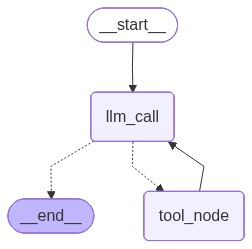

In [75]:
# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_call")

# Compile the agent
agent = agent_builder.compile()

# Show the agent
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))



In [76]:
# Invoke
from langchain.messages import HumanMessage
# messages = [HumanMessage(content="Calculate (3 + 4) * 2 + (6 + 14) / (7 * 5 + 2)")]
# messages = agent.invoke({"messages": messages})
# for m in messages["messages"]:
#     m.pretty_print()

inputs = {"messages": [HumanMessage(content="Calculate (3 + 4) * 2 + (6 + 14) / (7 * 5 + 2)")]}

# .stream() returns a generator that yields updates after each node finishes
for chunk in agent.stream(inputs, stream_mode="values"):
    # Grab the last message added to the state in this chunk
    new_message = chunk["messages"][-1]
    new_message.pretty_print()
    # print("-" * 30) # Visual separator for each step

================================ Human Message =================================

Calculate (3 + 4) * 2 + (6 + 14) / (7 * 5 + 2)
================================== Ai Message ==================================
Tool Calls:
  add (call_7akuP0xfoFbfkUYfqg6dQmRB)
 Call ID: call_7akuP0xfoFbfkUYfqg6dQmRB
  Args:
    a: 3
    b: 4
  add (call_VnLllgWJbBe0QFkm9X6N9F10)
 Call ID: call_VnLllgWJbBe0QFkm9X6N9F10
  Args:
    a: 6
    b: 14
  multiply (call_xq2iDssypRkx1SZXJ4V4nuQQ)
 Call ID: call_xq2iDssypRkx1SZXJ4V4nuQQ
  Args:
    a: 7
    b: 5
================================= Tool Message =================================

35
================================== Ai Message ==================================
Tool Calls:
  multiply (call_fAEOcCZ4navjGVd06kUIbfCr)
 Call ID: call_fAEOcCZ4navjGVd06kUIbfCr
  Args:
    a: 7
    b: 2
  add (call_ddZuPb4Z7VcZlaTM4Jf08JCp)
 Call ID: call_ddZuPb4Z7VcZlaTM4Jf08JCp
  Args:
    a: 35
    b: 2
================================= Tool Message =====================

# 7. Add Current State problem for robustness

In [95]:
from typing import TypedDict, Annotated, Literal, List, Optional, Any
import operator
import json
from pydantic import BaseModel, Field, ConfigDict
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langgraph.graph import StateGraph, START, END

# 1. Enhanced State
class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    current_equation: str
    llm_calls: int 
    
# 2. Updated LLM Node
def tool_caller_node(state: MessagesState):
    # INSTEAD of with_structured_output, we bind the actual tools
    
    system_prompt = (
        "You are a helpful assistant tasked with performing arithmetic on a set of inputs, always use the provided tools to ensure accuracy."
    )
    
    # Invoke the model (returns an AIMessage)
    response = model_with_tools.invoke([SystemMessage(content=system_prompt)] + state["messages"])

    return {
        "messages": [response], # This is now a proper AIMessage with .tool_calls
        "llm_calls": state.get("llm_calls", 0) + 1,
    }
    
def equation_updater_node(state: MessagesState):
    system_prompt = (
        "You are an math agent to update an equation. "
        "You will receiving output from tools, you must update the 'current_equation' "
        "to a newer one using the output from the tools.\n"
        "Your output must be only a JSON block with one key 'updated_equation'"
        f"Current Equation State: {state.get('current_equation', 'Not started')}"
    )
    
    # Invoke the model (returns an AIMessage)
    response = model.invoke([SystemMessage(content=system_prompt)] + state["messages"])
    
    # --- Extraction Logic ---
    # We try to parse the 'thought_process' out of the message text 
    # to update our custom state variables without breaking tool_calls.
    updated_eq = state.get("current_equation", "")
    try:
        # Simple extraction if LLM followed instructions
        if "{" in response.content:
            json_str = response.content[response.content.find("{"):response.content.rfind("}")+1]
            data = json.loads(json_str)
            updated_eq = data.get("updated_equation", updated_eq)
    except:
        pass 

    return {
        "messages": [response], # This is now a proper AIMessage with .tool_calls
        "current_equation": updated_eq,
        "llm_calls": state.get("llm_calls", 0) + 1,
    }
    


# 3. Define the Tool Node (Same as your original)
def tool_node(state: MessagesState):
    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=str(observation), tool_call_id=tool_call["id"]))
    return {"messages": result}

# 4. Building the Graph
workflow = StateGraph(MessagesState)
workflow.add_node("tool_caller_node", tool_caller_node)
workflow.add_node("tool_node", tool_node)
workflow.add_node("equation_updater_node", equation_updater_node)

workflow.add_edge(START, "tool_caller_node")
workflow.add_conditional_edges("tool_caller_node", should_continue, ["tool_node", END])
workflow.add_edge("tool_node", "equation_updater_node")
workflow.add_edge("equation_updater_node", "tool_caller_node")

agent = workflow.compile()

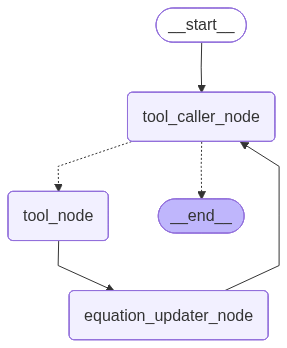

In [96]:
# Show the agent
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))



In [97]:
# Invoke
from langchain.messages import HumanMessage
import time

inputs = {"messages": [HumanMessage(content="Calculate (3 + 4) * 2 + (6 + 14) * (7 * 5 + 26 / 13)")]}

# .stream() returns a generator that yields updates after each node finishes
# Use streaming to see every message as it is added to the state
for chunk in agent.stream(inputs):
    for node, values in chunk.items():
        print(f"Update from node: {node}")
        for msg in values.get("messages", []):
            time.sleep(1)
            msg.pretty_print()

Update from node: tool_caller_node
================================== Ai Message ==================================
Tool Calls:
  add (call_CbZZ9ZnYDlh1WduiJMsSCUxB)
 Call ID: call_CbZZ9ZnYDlh1WduiJMsSCUxB
  Args:
    a: 3
    b: 4
  add (call_t5EkS2WRep1y5PJaDoOjKPIe)
 Call ID: call_t5EkS2WRep1y5PJaDoOjKPIe
  Args:
    a: 6
    b: 14
Update from node: tool_node
================================= Tool Message =================================

6
================================= Tool Message =================================

19
Update from node: equation_updater_node
================================== Ai Message ==================================

{"updated_equation": "(6) * 2 + (19) * (7 * 5 + 26 / 13)"}
Update from node: tool_caller_node
================================== Ai Message ==================================
Tool Calls:
  multiply (call_SUq3vjG0RGW3sVNtJNHd6o94)
 Call ID: call_SUq3vjG0RGW3sVNtJNHd6o94
  Args:
    a: 6
    b: 2
  multiply (call_PoeXeUhocZD5PT2MKRdyrOeG)
 Call